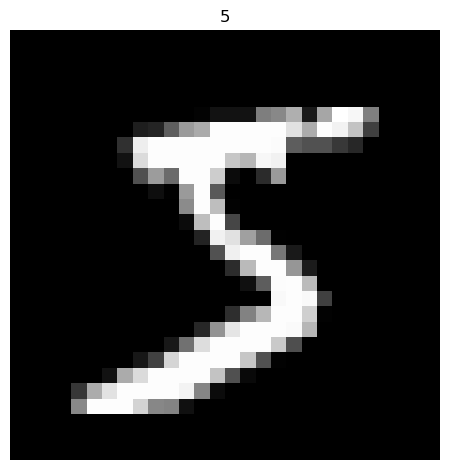

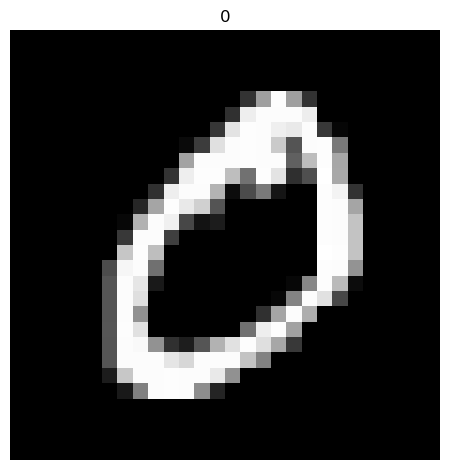

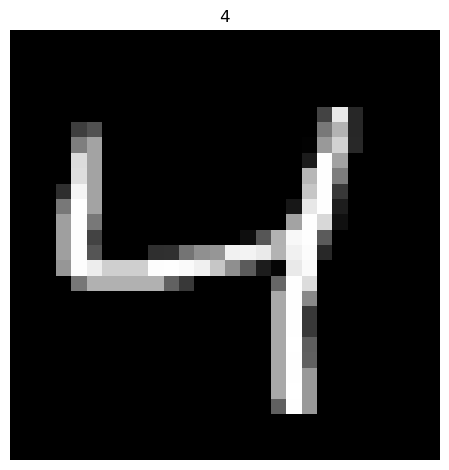

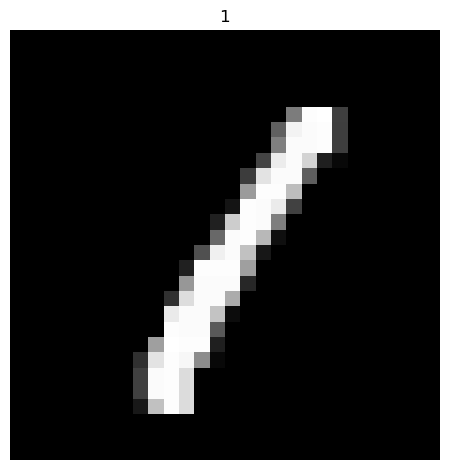

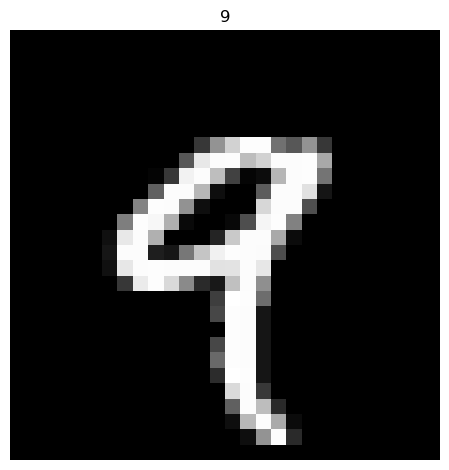

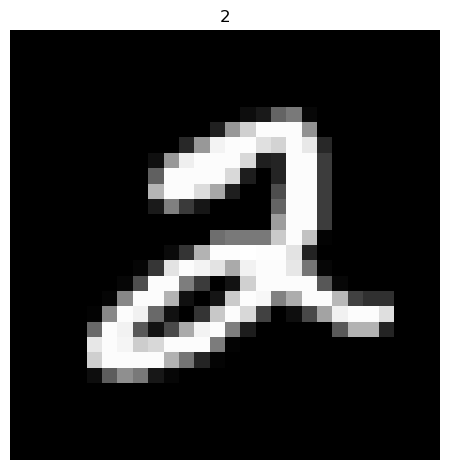

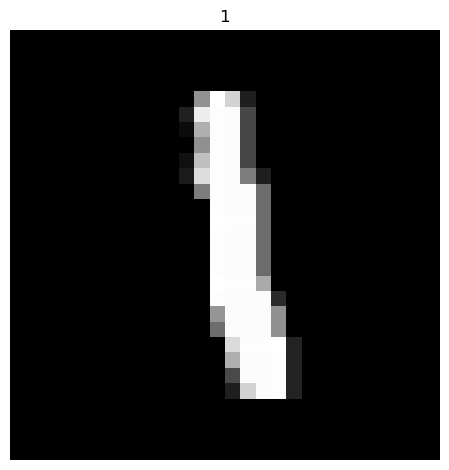

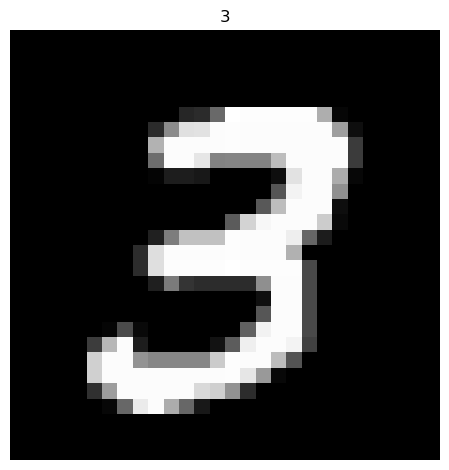

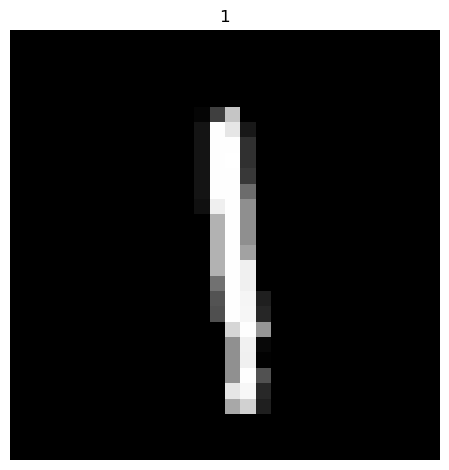

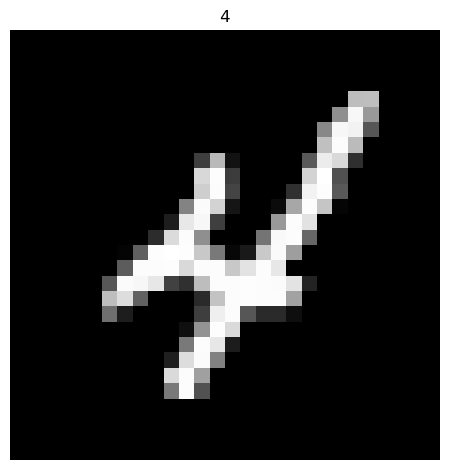

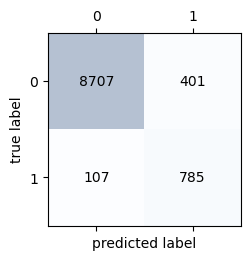

In [8]:
#--- Import MNIST ---

import pandas as pd
df = pd.read_csv('mnist_784.csv', header=0)
y = df.iloc[:, -1].values
X = df.iloc[:, 0:-1].values

# print(X.shape)
# print(y.shape)


# #--- Display MNIST images ---

import matplotlib.pyplot as plt

images_labels = list(zip(X, y))
for index,(image,label) in enumerate(images_labels[:10]):
  plt.axis('off')
  plt.imshow(image.reshape(28, 28), cmap='gray',
        interpolation='nearest')
  plt.title(label)
  plt.tight_layout()
  plt.show()



# #--- Generate a train and test set for digit 5 or non-5 ---

import numpy as np
y = y.astype(np.uint8)

X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

# True for all 5s, False for all other digits
y_train_5 = (y_train == 5) 
y_test_5 = (y_test == 5)


# #--- Build a binary classifier of digit 5 or non-5 ---

from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)


# #--- Model evaluation ---

from sklearn.metrics import accuracy_score
y_train_pred=sgd_clf.predict(X_train)
accuracy_score(y_train_5, y_train_pred)

y_test_pred=sgd_clf.predict(X_test)
accuracy_score(y_test_5, y_test_pred)


# #--- Confusion matrix ----

from sklearn.metrics import confusion_matrix
confmat = confusion_matrix(y_test_5, y_test_pred)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x=j, y=i, s=confmat[i, j], va='center', ha='center')
plt.xlabel('predicted label')
plt.ylabel('true label')
plt.show()


# #--- Precision, recall, F1-score ---

# from sklearn.metrics import precision_score, recall_score
# precision_score(y_test_5, y_test_pred)

# recall_score(y_test_5, y_test_pred)

# from sklearn.metrics import f1_score
# f1_score(y_test_5, y_test_pred)


# #==================================================================================

# #=== Code for cross-validation based on Scikit-Learn ===

# #--- Import MNIST ---

# import pandas as pd
# df = pd.read_csv('mnist_784.csv', header=0)
# y = df.iloc[:, -1].values
# X = df.iloc[:, 0:-1].values


# #--- Build a binary classifier of digit 5 or non-5 ---

# import numpy as np
# y = y.astype(np.uint8)

# # True for all 5s, False for all other digits
# y_5 = (y == 5) 

# from sklearn.linear_model import SGDClassifier
# sgd_clf = SGDClassifier(random_state=42)


# #--- Cross validation ----

# from sklearn.model_selection import cross_val_score
# cross_val_score(sgd_clf, X, y_5, cv=3, scoring="accuracy")

# from sklearn.model_selection import cross_val_predict
# y_pred = cross_val_predict(sgd_clf, X, y_5, cv=3)
# print(y_pred)

# from sklearn.metrics import confusion_matrix
# confusion_matrix(y_5, y_pred)

# from sklearn.metrics import precision_score, recall_score
# precision_score(y_5, y_pred)

# recall_score(y_5, y_pred)

# from sklearn.metrics import f1_score
# f1_score(y_5, y_pred)


# #--- ROC curve ---

# y_scores = cross_val_predict(sgd_clf, X, y_5, cv=3, method="decision_function")

# from sklearn.metrics import roc_curve
# fpr, tpr, thresholds = roc_curve(y_5, y_scores)

# def plot_roc_curve(fpr, tpr, label=None):
#   plt.plot(fpr, tpr, linewidth=2, label=label)
#   plt.plot([0, 1], [0, 1], 'k--') # Dashed diagon

# import matplotlib.pyplot as plt
# plot_roc_curve(fpr, tpr)
# plt.show()

# from sklearn.metrics import roc_auc_score
# roc_auc_score(y_5, y_scores)